In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch.utils.data import TensorDataset, DataLoader



     CNN ARCHITECTURE TASK

You must implement a CNN with the following layers:

1. Conv Layer 1
   - Input channels: 1
   - Output channels: 16
   - Kernel size: 3
   - Activation: ReLU
   - Followed by MaxPooling (2x2)

2. Conv Layer 2
   - Input channels: 16
   - Output channels: 32
   - Kernel size: 3
   - Activation: ReLU
   - Followed by MaxPooling (2x2)

3. Flatten Layer

4. Fully Connected Layer 1
   - Output features: 128
   - Activation: ReLU

5. Dropout Layer
   - Dropout rate: 0.3

6. Fully Connected Layer 2 (Output Layer)
   - Output features: 10 (number of classes)



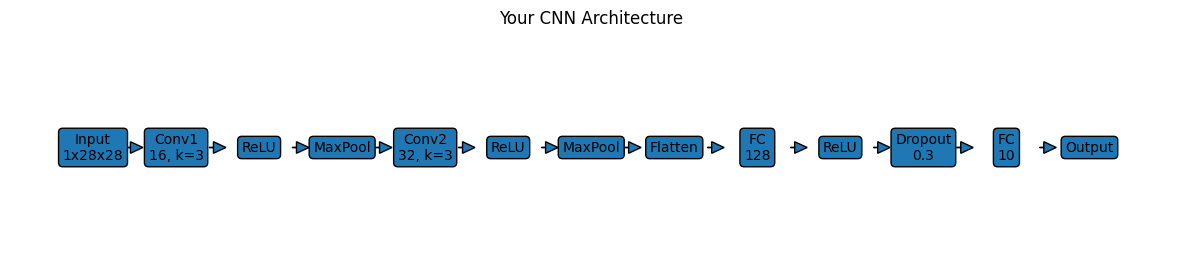

In [ ]:
# TODO: Enter your registration number
your_name = "___YOUR NAME HERE___"

seed = sum([ord(c) for c in your_name])

torch.manual_seed(seed)

# Architecture variation
k = 3 if seed % 2 == 0 else 5
f1 = 16 + (seed % 3) * 8
f2 = 32 + (seed % 3) * 8
dropout_rate = 0.3 + (seed % 2) * 0.2

print("\n==============================")
print("     CNN ARCHITECTURE TASK")
print("==============================\n")

print("You must implement a CNN with the following layers:\n")

print(f"1. Conv Layer 1")
print(f"   - Input channels: 1")
print(f"   - Output channels: {f1}")
print(f"   - Kernel size: {k}")
print(f"   - Activation: ReLU")
print(f"   - Followed by MaxPooling (2x2)\n")

print(f"2. Conv Layer 2")
print(f"   - Input channels: {f1}")
print(f"   - Output channels: {f2}")
print(f"   - Kernel size: {k}")
print(f"   - Activation: ReLU")
print(f"   - Followed by MaxPooling (2x2)\n")

print("3. Flatten Layer\n")

print("4. Fully Connected Layer 1")
print("   - Output features: 128")
print("   - Activation: ReLU\n")

print(f"5. Dropout Layer")
print(f"   - Dropout rate: {dropout_rate}\n")

print("6. Fully Connected Layer 2 (Output Layer)")
print("   - Output features: 10 (number of classes)\n")

# --------- PLOT DIAGRAM ---------
import matplotlib.pyplot as plt

layers = [
    "Input\n1x28x28",
    f"Conv1\n{f1}, k={k}",
    "ReLU",
    "MaxPool",
    f"Conv2\n{f2}, k={k}",
    "ReLU",
    "MaxPool",
    "Flatten",
    "FC\n128",
    "ReLU",
    f"Dropout\n{dropout_rate}",
    "FC\n10",
    "Output"
]

fig, ax = plt.subplots(figsize=(15, 3))

for i, layer in enumerate(layers):
    ax.text(i, 0, layer, ha='center', va='center', bbox=dict(boxstyle="round"))

    if i < len(layers) - 1:
        ax.arrow(i + 0.4, 0, 0.2, 0, length_includes_head=True, head_width=0.1)

ax.set_xlim(-1, len(layers))
ax.set_ylim(-1, 1)
ax.axis('off')

plt.title("Your CNN Architecture")
plt.show()

In [16]:
# TODO: Load MNIST dataset from local file (mnist.npz)

data = np.load("mnist.npz")

x_train = data["x_train"]
y_train = data["y_train"]
x_test = data["x_test"]
y_test = data["y_test"]

print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [17]:
# TODO:
#  1. Normalize images (0-1 range)
#  2. Convert to torch tensors
#  3. Add channel dimension
#  training split shape should be torch.Size([60000, 1, 28, 28])

# YOUR CODE HERE

x_train_t = torch.tensor(x_train / 255.0, dtype=torch.float32).unsqueeze(1)
x_test_t  = torch.tensor(x_test  / 255.0, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

print(x_train_t.shape)   # should be torch.Size([60000, 1, 28, 28])

torch.Size([60000, 1, 28, 28])


In [18]:
# TODO: Create DataLoader for train and test sets

# YOUR CODE HERE

train_dataset = TensorDataset(x_train_t, y_train_t)
test_dataset  = TensorDataset(x_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [30]:
# TODO: Define CNN model
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, seed):
        super(CNN, self).__init__()

        # TODO: Define layers
        # Conv1
        self.conv1   = nn.Conv2d(1, f1, kernel_size=k)
        # Conv2
        self.conv2   = nn.Conv2d(f1, f2, kernel_size=k)
        # Fully connected layers
        self.fc1     = nn.Linear(f2 * 4 * 4, 128)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2     = nn.Linear(128, 10)

    def forward(self, x):
        # TODO: Define forward pass
        # conv → relu → pool
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        # conv → relu → pool
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        # Flatten
        x = x.view(x.size(0), -1)
        # FC layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN(seed)
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [31]:
# TODO: Define loss function and optimizer
import torch.optim as optim

# YOUR CODE HERE
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [32]:
# TODO: Write training loop
epochs     = 5
train_loss = []
test_loss  = []

for epoch in tqdm(range(epochs)):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train = running_loss / len(train_loader)
    train_loss.append(avg_train)

    # ---- Test loss ----
    model.eval()
    running_test = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs       = model(images)
            loss          = criterion(outputs, labels)
            running_test += loss.item()

    avg_test = running_test / len(test_loader)
    test_loss.append(avg_test)

    print(f"Epoch {epoch+1} completed | Train Loss: {avg_train:.4f} | Test Loss: {avg_test:.4f}")

 20%|██        | 1/5 [00:06<00:26,  6.65s/it]

Epoch 1 completed | Train Loss: 0.3050 | Test Loss: 0.0661


 40%|████      | 2/5 [00:12<00:19,  6.42s/it]

Epoch 2 completed | Train Loss: 0.1053 | Test Loss: 0.0484


 60%|██████    | 3/5 [00:19<00:12,  6.39s/it]

Epoch 3 completed | Train Loss: 0.0771 | Test Loss: 0.0374


 80%|████████  | 4/5 [00:25<00:06,  6.36s/it]

Epoch 4 completed | Train Loss: 0.0601 | Test Loss: 0.0305


100%|██████████| 5/5 [00:31<00:00,  6.38s/it]

Epoch 5 completed | Train Loss: 0.0494 | Test Loss: 0.0318


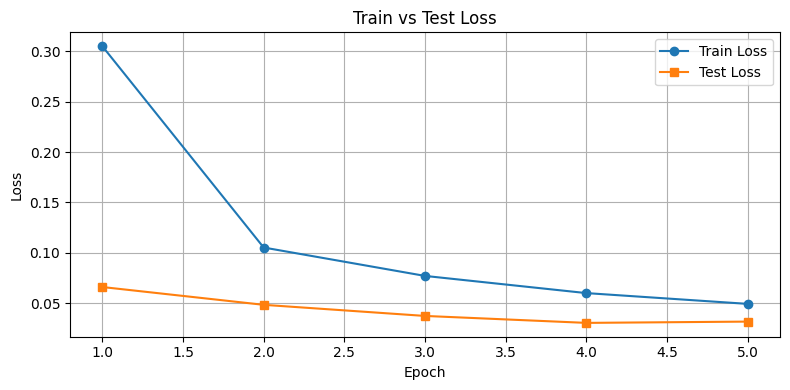

In [33]:
# TODO: Plot train loss and test loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_loss, label="Train Loss", marker='o')
plt.plot(range(1, epochs + 1), test_loss,  label="Test Loss",  marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
# TODO: Evaluate model on test set — Calculate accuracy
correct = 0
total   = 0

# YOUR CODE HERE
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs      = model(images)
        _, predicted = torch.max(outputs, 1)
        total       += labels.size(0)
        correct     += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 98.92


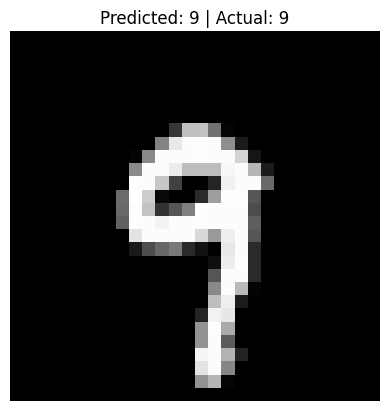

In [38]:
# TODO: Evaluate model on test set sample

import random

model.eval()

# Pick a random index
idx = random.randint(0, len(x_test) - 1)

# Get image and label
image     = x_test_t[idx]
label     = y_test_t[idx]
predicted = 0

# Add batch dimension (1, 1, 28, 28)
input_img = image.unsqueeze(0)

# Prediction
# YOUR CODE HERE — input_img → model → update predicted
with torch.no_grad():
    output    = model(input_img)
    predicted = torch.argmax(output, dim=1).item()

# Convert image for display
img_display = image.squeeze().numpy()

# Plot image
plt.imshow(img_display, cmap='gray')
plt.title(f"Predicted: {predicted} | Actual: {label.item()}")
plt.axis('off')
plt.show()